In [33]:
from pathlib import Path
import pandas as pd 
import folium as fl
import osmnx as ox
import matplotlib.pyplot as plt 
import geopandas as gpd

Code block to ensure files are read,created and saved in the right folders

In [34]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory    

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"processed"
figures_directory = project_root/"outputs"/"figures"
maps_directory = project_root/"outputs"/"maps"

for directory in [raw_data_directory,processed_data_directory,figures_directory,maps_directory]:
    directory.mkdir(parents=True,exist_ok=True)

print("Project Root:",project_root)
print("Folders are ready")

Project Root: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis
Folders are ready


In [69]:
#Saving Json locally so there is no need to also always get data

ox.settings.use_cache = True
ox.settings.log_console = True

accra_boundary = ox.geocode_to_gdf("Accra, Ghana")
accra_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-0.28427 5.52014, -0.28406 5.51965, ...",-0.284271,5.516926,-0.054857,5.667368,299395220,relation,12803764,5.55711,-0.201238,boundary,administrative,16,0.652835,city,Accra,"Accra, Korle-Klottey Municipal District, Great..."


In [ ]:
print("Number of records:", len(accra_boundary))
print("CRS:", accra_boundary.crs)
print("Geometry type:", accra_boundary.geometry.geom_type.iloc[0])

accra_boundary[["display_name", "geometry"]]

In [70]:
print(accra_boundary["display_name"].iloc[0])

Accra, Korle-Klottey Municipal District, Greater Accra Region, Ghana


The entire boundary for Greater different from the above which covers only some part

In [71]:
greater_accra_boundary = ox.geocode_to_gdf({"state":"Greater Accra Region","Country":"Ghana",})

In [72]:
print(greater_accra_boundary["display_name"].iloc[0])
print("CRS:",greater_accra_boundary.crs)
print("Geometry Type:",greater_accra_boundary.geometry.geom_type.iloc[0])

Greater Accra Region, Ghana
CRS: epsg:4326
Geometry Type: Polygon


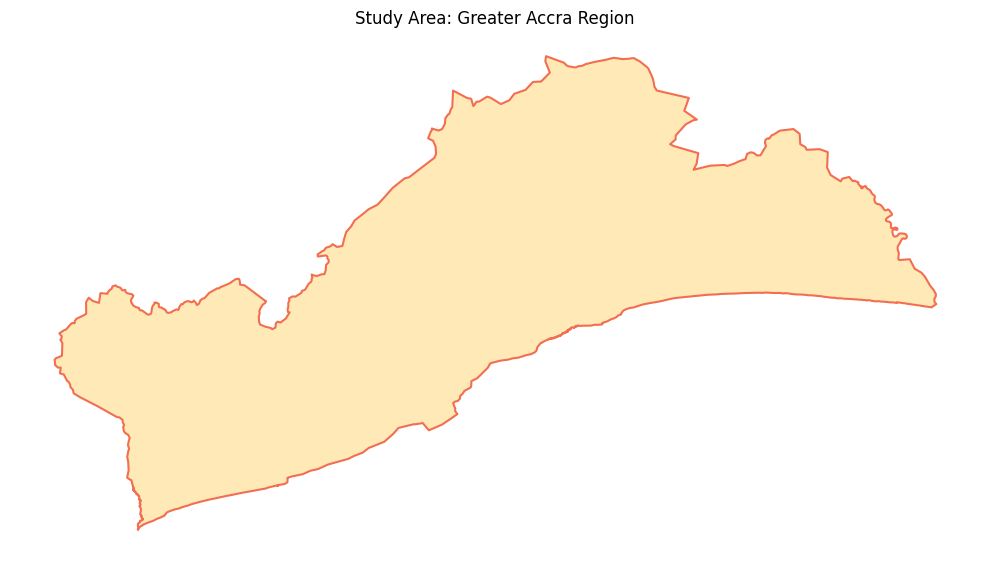

In [76]:
fig,ax = plt.subplots(figsize=(10,10))
greater_accra_boundary.plot(ax=ax,facecolor="#ffeab7",edgecolor="#f36e50",linewidth=1.5)
ax.set_title("Study Area: Greater Accra Region")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [81]:
#Saving of the boundary of greater Accra Locally

greater_accra_boundary_file =(raw_data_directory/"greater_accra_boundary.geojson")
greater_accra_boundary.to_file(greater_accra_boundary_file,driver="GeoJSON",)

print("File exist:",greater_accra_boundary_file.exists(),)
print("saved to:",greater_accra_boundary_file,)

File exist: True
saved to: /Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/data/raw/greater_accra_boundary.geojson
